In [64]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt 
import cv2 as cv
import shutil

In [65]:
file_names = ['209_101_24_JPG.rf.865089eccbc0c33accfc32623ac046ed', # [0]  0.6537 (887, 558) ✓ 
            '209_205_50_JPG.rf.949b5aa6fdbf6a1f721c39ed5ddcebec', # [1]  0.6884 (695, 608) ✓ 
            '209_310_37_JPG.rf.fc1bab0d312b2f3ded60d51f809b6a2d', # [2]  0.6996 (831, 663) ✓ 
            '209_413_15_JPG.rf.94b7dd36f092b97bcb604cfdddfe3fc0', # [3]  0.6885 (872, 436) ✓ 
            '503_118_29_JPG.rf.33b1e23ce2d5d55c753d42f7fae09523', # [4]  0.7082 (625, 418) ✓ 
            '503_222_19_JPG.rf.d34e87d9c5dbe27a14ef87f2ca66f883'] # [5]


print("Indexes: 0 -",len(file_names)-1)

Indexes: 0 - 5


In [66]:
file_name = file_names[5]
origin_labels_file = f'./Labels/3.5m.v2i.yolov8/train/labels/{file_name}.txt'
origin_image_file = f'./Labels/3.5m.v2i.yolov8/train/images/{file_name}.jpg'
file_name

'503_222_19_JPG.rf.d34e87d9c5dbe27a14ef87f2ca66f883'

In [67]:
short_file_name = file_name[:file_name.find('rf')-1-4]
dest_image_file = f'../images/5m90/{short_file_name}.JPG'
dest_folder = '5m.v2i.yolov8'

In [68]:
origin_folder = origin_labels_file[origin_labels_file.find('/Labels/')+len('/Labels/'):origin_labels_file.find('/train/')]
dest_labels_file = origin_labels_file.replace(origin_folder,dest_folder)
dest_labels_file

'./Labels/5m.v2i.yolov8/train/labels/503_222_19_JPG.rf.d34e87d9c5dbe27a14ef87f2ca66f883.txt'

---

In [69]:
root = '../../data/raw/5m.v3i.yolov8/train/'
file_name = '209_415_13_JPG.rf.720dfb80a17b615a8d23d82288e49912'
origin_labels_file = f'{root}labels/{file_name}.txt'
origin_image_file = f'{root}images/{file_name}.jpg'
origin_labels_file, origin_image_file

('../../data/raw/5m.v3i.yolov8/train/labels/209_415_13_JPG.rf.720dfb80a17b615a8d23d82288e49912.txt',
 '../../data/raw/5m.v3i.yolov8/train/images/209_415_13_JPG.rf.720dfb80a17b615a8d23d82288e49912.jpg')

In [70]:
dest_folder = '../../data/processed/5m.v3i.yolov8_scaled3.5m/'
dest_image_file = f'{dest_folder}{file_name}.jpg'
dest_labels_file = f'{dest_folder}{file_name}.txt'
dest_image_file, dest_labels_file

('../../data/processed/5m.v3i.yolov8_scaled3.5m/209_415_13_JPG.rf.720dfb80a17b615a8d23d82288e49912.jpg',
 '../../data/processed/5m.v3i.yolov8_scaled3.5m/209_415_13_JPG.rf.720dfb80a17b615a8d23d82288e49912.txt')

### Helper Functions

In [71]:
def load_and_show(path: str):
    image = cv.imread(path)
    
    img = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    plt.figure(figsize=(12,8))
    plt.imshow(img)
    plt.show()
    
    return img

In [72]:
def label_transform(df_labels: pd.DataFrame, mode: str, im_height: int = 3648, im_width: int = 5472, round: bool = True) -> pd.DataFrame:
    """
    Transforms bounding box coordinates based on the specified mode.

    Args:
        df_labels: DataFrame containing bounding box coordinates (x, y, width, height).
        mode: Transformation mode ('absolute' or 'relative').
        im_height: Image height in pixels (default: 3648).
        im_width: Image width in pixels (default: 5472).

    Returns:
        Transformed DataFrame with bounding box coordinates.

    Raises:
        AssertionError: If im_width or im_height is not an integer.
        ValueError: If mode is not 'absolute' or 'relative'.
    """

    assert isinstance(im_width, int), "Dimensions should be int numbers."
    assert isinstance(im_height, int), "Dimensions should be int numbers."
    assert isinstance(mode, str), "Mode should be a string"    
    assert isinstance(df_labels, pd.DataFrame), "df_labels must be a pandas DataFrame"

    if im_height == 0 or im_height == 0:
        raise ValueError("Debe introducir las dimensiones de la imagen (no pueden ser 0).")
    if mode == 'absolute':
        df_labels_abs = df_labels * [1, im_width, im_height, im_width, im_height]
        if round:
            df_labels_abs = df_labels_abs.round(0).astype(int)
        df_labels_abs['class_id'] = df_labels_abs['class_id'].astype(int)
        return df_labels_abs
    elif mode == 'relative':
        df_labels_rel = df_labels / [1, im_width, im_height, im_width, im_height]
        df_labels_rel['class_id'] = df_labels_rel['class_id'].astype(int)
        return df_labels_rel
    else:
        raise ValueError("Debe indicar el modo de transformación deseado ('absolute' o 'relative')")
    

## Settings

In [73]:
y_fine = 0
x_fine = 0

In [74]:
# Set up parameters
scale = 28.7450726400/13.3515145559
x_offset = 0 + x_fine
y_offset = 0 + y_fine

In [75]:
scale

2.15294471047838

### Loading all files

#### Input labels

In [76]:
with open(origin_labels_file, 'r') as file:
    lines = file.readlines()
    lines = [line.strip() for line in lines]
    labels = [line.split() for line in lines]

In [77]:
# Convierte de string a int/float
in_labels = [[int(value) if i == 0 else float(value) 
          for i, value in enumerate(label)] for label in labels]

class_id | x_center | y_center | width | height (normalized values)

In [78]:
df_in_labels = pd.DataFrame(in_labels, columns=['class_id', 'x_center', 'y_center', 'width', 'height'])

In [79]:
df_in_labels

,class_id,x_center,y_center,width,height
0,2,0.012840,0.036711,0.003514,0.005238
1,2,0.019830,0.031831,0.006089,0.006804
2,2,0.018273,0.033550,0.004583,0.005905
3,2,0.023889,0.034550,0.005535,0.005255
4,2,0.021701,0.039216,0.006299,0.001820
...,...,...,...,...,...
2711,2,0.692381,0.893237,0.001897,0.010836
2712,0,0.691893,0.888736,0.003620,0.005515
2713,0,0.688118,0.887111,0.003262,0.005137
2714,1,0.739686,0.935946,0.002363,0.002845


In [80]:
# Agrego un punto en cada esquina de la imagen para debugging
# Crear una nueva fila como un Series o DataFrame
upleft = pd.Series({'class_id': 0, 'x_center': 0, 'y_center': 0, 'width': 0, 'height': 0})
upright = pd.Series({'class_id': 0, 'x_center': 1, 'y_center': 0, 'width': 0, 'height': 0})
downleft = pd.Series({'class_id': 0, 'x_center': 0, 'y_center': 1, 'width': 0, 'height': 0})
downright = pd.Series({'class_id': 0, 'x_center': 1, 'y_center': 1, 'width': 0, 'height': 0})


# Concatenar la nueva fila al DataFrame existente
df_in_labels = pd.concat([df_in_labels, upleft.to_frame().T], ignore_index=True)
df_in_labels = pd.concat([df_in_labels, upright.to_frame().T], ignore_index=True)
df_in_labels = pd.concat([df_in_labels, downleft.to_frame().T], ignore_index=True)
df_in_labels = pd.concat([df_in_labels, downright.to_frame().T], ignore_index=True)

df_in_labels.tail(6)

,class_id,x_center,y_center,width,height
2714,1,0.739686,0.935946,0.002363,0.002845
2715,1,0.735499,0.944282,0.004872,0.003336
2716,0,0.000000,0.000000,0.000000,0.000000
2717,0,1.000000,0.000000,0.000000,0.000000
2718,0,0.000000,1.000000,0.000000,0.000000
2719,0,1.000000,1.000000,0.000000,0.000000


#### Input image

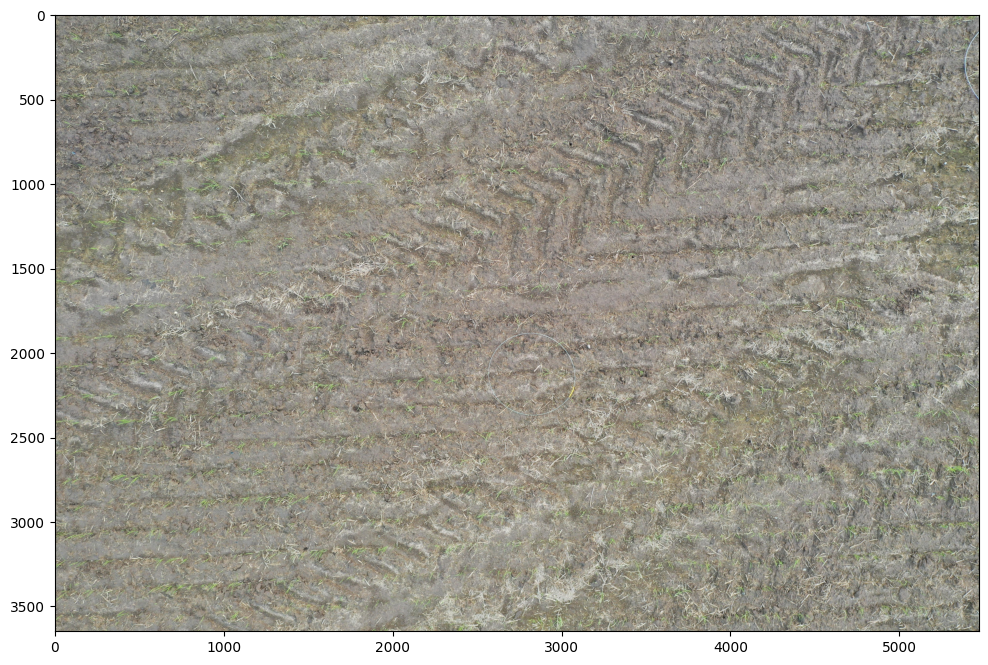

In [81]:
in_image = load_and_show(origin_image_file)

In [82]:
Hi, Wi, _ = in_image.shape
in_image.shape

(3648, 5472, 3)

(height, width, channels) 

# Transform IMG

In [84]:
# Scale the image
scaled_image = cv.resize(in_image, None, fx=scale, fy=scale, interpolation=cv.INTER_LINEAR)

# Save the scaled image
cv.imwrite(dest_image_file, cv.cvtColor(scaled_image, cv.COLOR_RGB2BGR))
print(f"Image scaled and saved to {dest_image_file}")

Image scaled and saved to ../../data/processed/5m.v3i.yolov8_scaled3.5m/209_415_13_JPG.rf.720dfb80a17b615a8d23d82288e49912.jpg


#### Output image

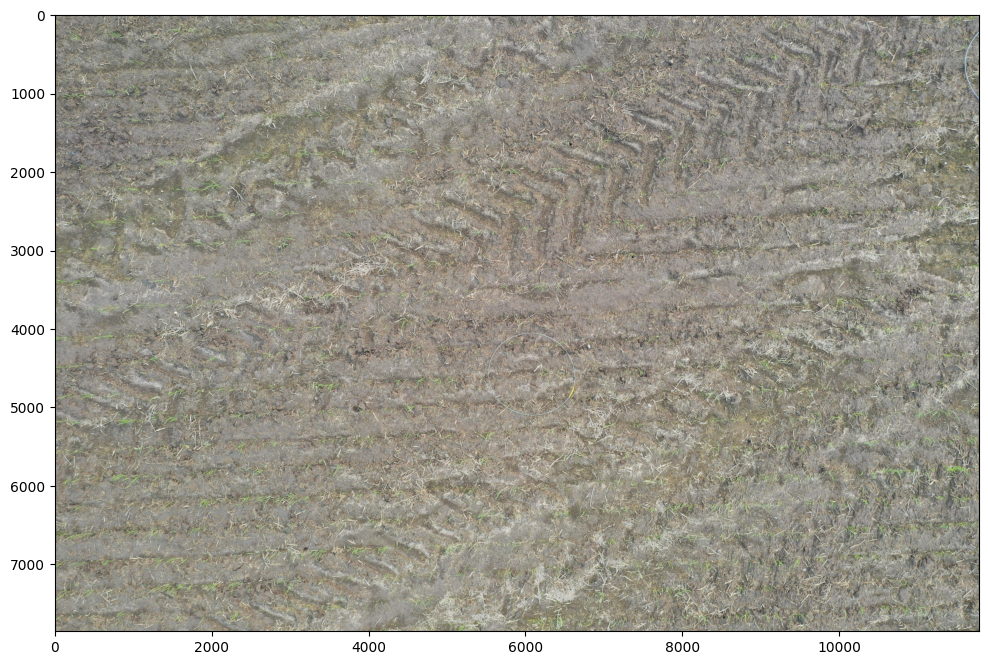

In [85]:
out_image = load_and_show(dest_image_file)

In [86]:
Ho, Wo, _ = out_image.shape
out_image.shape

(7854, 11781, 3)

(height, width, channels) 

#### Validación dimensional

In [87]:
# Verificar dimensiones
if (Hi, Wi) == (Ho, Wo):
    print("Validación dimensional pasada con éxito.")
else:
    print("Alguna de las dimensiones no coinciden.")
    print('input:',(Hi,Wi),'output:',(Ho,Wo))

Alguna de las dimensiones no coinciden.
input: (3648, 5472) output: (7854, 11781)


# BB Transofrmation

In [89]:
df_in_labels_abs = label_transform(df_in_labels,'absolute', round=False)
df_in_labels_abs

,class_id,x_center,y_center,width,height
0,2,70.26,133.92,19.23,19.11
1,2,108.51,116.12,33.32,24.82
2,2,99.99,122.39,25.08,21.54
3,2,130.72,126.04,30.29,19.17
4,2,118.75,143.06,34.47,6.64
...,...,...,...,...,...
2715,1,4024.65,3444.74,26.66,12.17
2716,0,0.00,0.00,0.00,0.00
2717,0,5472.00,0.00,0.00,0.00
2718,0,0.00,3648.00,0.00,0.00


### Scaling labels

In [90]:
scale

2.15294471047838

In [91]:
df_labels_scaled = df_in_labels_abs * [1, scale, scale, scale, scale]
df_labels_scaled

,class_id,x_center,y_center,width,height
0,2.0,151.265895,288.322356,41.401127,41.142773
1,2.0,233.616031,249.999940,71.736118,53.436088
2,2.0,215.272942,263.498903,53.995853,46.374429
3,2.0,281.432933,271.357151,65.212695,41.271950
4,2.0,255.662184,308.000270,74.212004,14.295553
...,...,...,...,...,...
2715,1.0,8664.848929,7416.334762,57.397506,26.201337
2716,0.0,0.000000,0.000000,0.000000,0.000000
2717,0.0,11780.913456,0.000000,0.000000,0.000000
2718,0.0,0.000000,7853.942304,0.000000,0.000000


### Offset labels

In [92]:
x_offset, y_offset

(0, 0)

In [93]:
df_labels_off = df_labels_scaled + [0, x_offset, y_offset, 0, 0]
df_labels_off

,class_id,x_center,y_center,width,height
0,2.0,151.265895,288.322356,41.401127,41.142773
1,2.0,233.616031,249.999940,71.736118,53.436088
2,2.0,215.272942,263.498903,53.995853,46.374429
3,2.0,281.432933,271.357151,65.212695,41.271950
4,2.0,255.662184,308.000270,74.212004,14.295553
...,...,...,...,...,...
2715,1.0,8664.848929,7416.334762,57.397506,26.201337
2716,0.0,0.000000,0.000000,0.000000,0.000000
2717,0.0,11780.913456,0.000000,0.000000,0.000000
2718,0.0,0.000000,7853.942304,0.000000,0.000000


### Formateo

In [94]:
# Se debe transformar al formato original de YOLO (posición relativa)
df_out_labels = label_transform(df_labels_off,'relative')
df_out_labels

,class_id,x_center,y_center,width,height
0,2,0.027644,0.079036,0.007566,0.011278
1,2,0.042693,0.068531,0.013110,0.014648
2,2,0.039341,0.072231,0.009868,0.012712
3,2,0.051431,0.074385,0.011918,0.011314
4,2,0.046722,0.084430,0.013562,0.003919
...,...,...,...,...,...
2715,1,1.583488,2.032987,0.010489,0.007182
2716,0,0.000000,0.000000,0.000000,0.000000
2717,0,2.152945,0.000000,0.000000,0.000000
2718,0,0.000000,2.152945,0.000000,0.000000


# Visualización (para verificación)

Se debe verificar que los centroides de los BB coinciden efectivamente con las plantas

### Imagenes con centroides

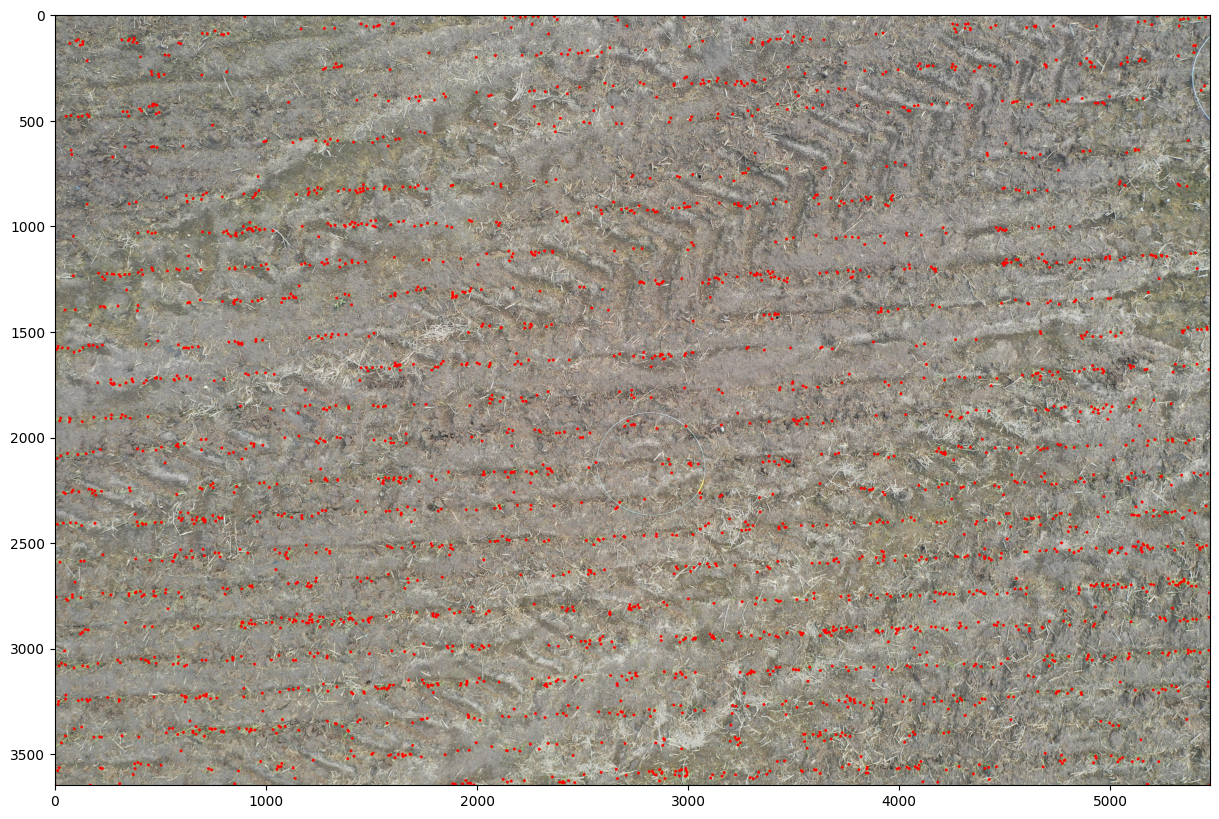

In [95]:
dataframe = label_transform(df_in_labels,'absolute')
graph_img = in_image.copy()

# Grafica imagen origen
for _, row in dataframe.iterrows():
    x = row['x_center']
    y = row['y_center']
    point = [x, y]
    
    # Dibujar los círculos
    cv.circle(graph_img, center=point, radius=7, color=(255, 0, 0), thickness=-1)

# Mostrar imagen con puntos
fig = plt.figure(figsize=(20, 10))
plt.imshow(graph_img)
plt.show()

In [96]:
point_ini = [x_offset, y_offset]
print(point_ini)
img_size = [Wo, Ho]
print(img_size)
img_size = np.dot(img_size, scale)
print(img_size)
point_end = point_ini + img_size
point_end = point_end.round().astype(int).tolist()

print(point_ini,'->',point_end)


[0, 0]
[11781, 7854]
[25363.84163415 16909.2277561 ]
[0, 0] -> [25364, 16909]


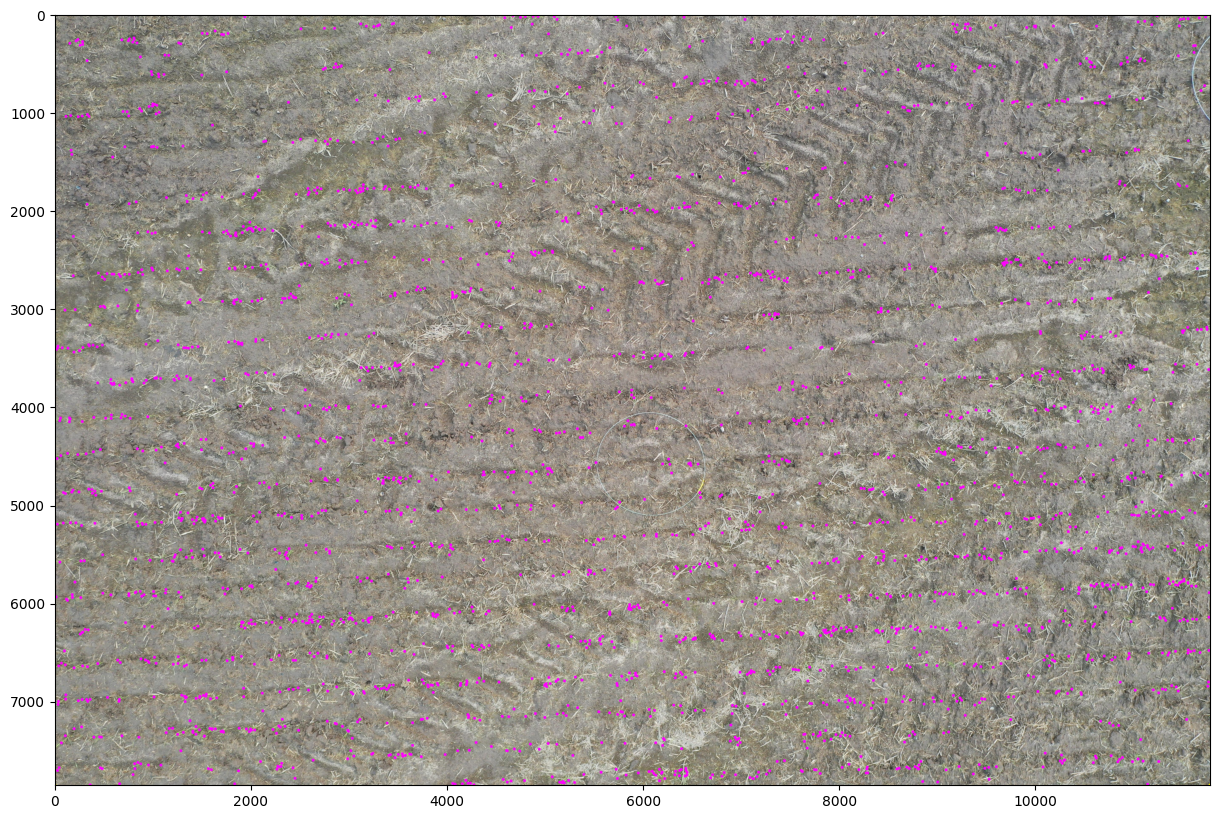

In [101]:
dataframe = label_transform(df_out_labels,'absolute')
graph_img = out_image.copy()
size = len(dataframe)

# Graficar offset
cv.rectangle(graph_img, point_ini, point_end,(0,255,0),3)

# Grafica imagen destino
for i, row in dataframe.iterrows():
    x = row['x_center']
    y = row['y_center']
    point = [x, y]
    
    # Dibujar los círculos
    cv.circle(graph_img, center=point, radius=15, color=(255, 0, 255), thickness=-1)
    if i >= size - 4:
        cv.circle(graph_img, center=point, radius=15, color=(255, 255, 0), thickness=-1)
        

# Mostrar imagen con puntos
fig = plt.figure(figsize=(20, 10))
plt.imshow(graph_img)
plt.show()

In [98]:
1/0 # Para interrumpir la ejecución 

ZeroDivisionError: division by zero

# Exportación de etiquetas

## Copiado de imagen nueva al dataset

In [102]:
new_image_file = origin_image_file.replace(origin_folder,dest_folder) # directorio de destino

print("ALERTA: Se realizará la sustitución de la imagen del dataset original por la nueva imagen")
print("- Origen:", origin_image_file)
print("- Copiando:", dest_image_file)
print("- Destino:", new_image_file)

ALERTA: Se realizará la sustitución de la imagen del dataset original por la nueva imagen
- Origen: ../../data/raw/5m.v3i.yolov8/train/images/209_415_13_JPG.rf.720dfb80a17b615a8d23d82288e49912.jpg
- Copiando: ../../data/processed/5m.v3i.yolov8_scaled3.5m/209_415_13_JPG.rf.720dfb80a17b615a8d23d82288e49912.jpg
- Destino: ../../data/raw/5m.v3i.yolov8/train/images/209_415_13_JPG.rf.720dfb80a17b615a8d23d82288e49912.jpg


In [103]:
try:
    if not os.path.exists(os.path.dirname(new_image_file)):
        raise FileNotFoundError(f"Destination directory '{os.path.dirname(new_image_file)}' does not exist.")
    shutil.copyfile(dest_image_file, new_image_file)
    print(f"Copiado existosamente: {new_image_file}")
except Exception as e:
    print(f"Error copying image '{origin_image_file}': {e}")

Copiado existosamente: ../../data/raw/5m.v3i.yolov8/train/images/209_415_13_JPG.rf.720dfb80a17b615a8d23d82288e49912.jpg


## Generación del nuevo archivo de etiquetas

### Elimina datos para debugging

In [104]:
df_out_labels.tail(6)

,class_id,x_center,y_center,width,height
2714,1,1.592502,2.015039,0.005087,0.006126
2715,1,1.583488,2.032987,0.010489,0.007182
2716,0,0.000000,0.000000,0.000000,0.000000
2717,0,2.152945,0.000000,0.000000,0.000000
2718,0,0.000000,2.152945,0.000000,0.000000
2719,0,2.152945,2.152945,0.000000,0.000000


In [105]:
# Remove last 4 rows (used for debugging)
df_out_labels.drop(df_out_labels.tail(4).index, inplace=True) 

In [106]:
df_out_labels.tail(6)

,class_id,x_center,y_center,width,height
2710,1,1.482947,1.912114,0.010446,0.005170
2711,2,1.490658,1.923091,0.004084,0.023329
2712,0,1.489608,1.913400,0.007794,0.011874
2713,0,1.481479,1.909900,0.007023,0.011060
2714,1,1.592502,2.015039,0.005087,0.006126
2715,1,1.583488,2.032987,0.010489,0.007182


### Adapta el formato de los datos

In [107]:
# Convert each row to a string
lines = []
for _, row in df_out_labels.iterrows():
    row_list = list(row)
    row_list[0] = int(row_list[0])
    line = ' '.join(map(str, row_list))
    lines.append(line)
lines[:10]

['2 0.027643621227743234 0.0790357334504563 0.007565995391538605 0.011278172537621119',
 '2 0.04269298803618586 0.06853068524691598 0.01310967064202113 0.014648050360217485',
 '2 0.03934081535101118 0.07223105896805068 0.009867663256359242 0.01271228866877859',
 '2 0.05143145697253907 0.07438518402102384 0.011917524722293519 0.011313582812464513',
 '2 0.04672189041836762 0.08442989865160007 0.013562135265020057 0.003918737082668981',
 '2 0.05153768779706926 0.08215183763667501 0.018008091995357356 0.0056066268502041145',
 '2 0.1475821565973027 0.06865462120886787 0.018181208894591728 0.009194868034334747',
 '2 0.13893418058554927 0.06669525266753337 0.018484163468251876 0.01443558871115712',
 '2 0.13663644719571122 0.07142252435912651 0.009080768259839367 0.005388263488669849',
 '2 0.12437268867494895 0.06929790786852286 0.013255246216377305 0.0037357839959781098']

In [108]:
# Verificar que la cantidad de lineas coincide con la cantidad de labels
if not len(lines) == len(df_out_labels):
    print("CUIDADO: Faltan labels en el archivo de salida")

### Almacena los datos

**"a":**  The texts will be inserted at the current file stream position, default at the end of the file.

**"w":** The file will be emptied before the texts will be inserted at the current file stream position, default 0.

In [109]:
with open(dest_labels_file, 'w') as file:
    #file.writelines(lines)
    for line in lines:
        file.write(line+"\n")

    if os.path.exists(dest_labels_file):
        print("El archivo de etiquetas se ha creado correctamente y se han escrito los datos.")
    else:
        print("Ocurrió un error al crear el archivo!")

El archivo de etiquetas se ha creado correctamente y se han escrito los datos.


#### Verificación de decimales para cada feature
**Median & mode:**
- 16 x_center/y_center
- 18 width/height
 
**Max valeue:**
- 21 decimales

In [110]:
len_x,len_y,len_w,len_h = [],[],[],[]
for i, label in enumerate(in_labels):
    for j, value in enumerate(label):
        value = str(value)
        match j:
            case 0:
                pass
            case 1:
                len_x.append(len(value))
            case 2:
                len_y.append(len(value))
            case 3:
                len_w.append(len(value))
            case 4:
                len_h.append(len(value))

In [111]:
from scipy import stats as st
# Calcula la moda
len_np = np.array([len_x, len_y, len_w, len_h])
for x in len_np:
    #median_value = np.median(x)
    median_value = st.mode(x)
    result = int(median_value.mode - 2)
    print(result)

16
16
18
18


In [112]:
# Calcula la media
len_np = np.array([len_x, len_y, len_w, len_h])
for x in len_np:
    median_value = np.median(x)
    result = int(median_value - 2)
    print(result)

16
16
18
18


In [113]:
print("",len_np[0].max(),"\n",
len_np[1].max(),"\n",
len_np[2].max(),"\n",
len_np[3].max())

 21 
 21 
 22 
 22


In [114]:
in_labels[:4]

[[2,
  0.012839912280701755,
  0.03671052631578947,
  0.0035142543859649124,
  0.005238486842105263],
 [2,
  0.019830043859649125,
  0.031831140350877196,
  0.0060891812865497075,
  0.006803728070175439],
 [2,
  0.018273026315789472,
  0.033549890350877194,
  0.004583333333333333,
  0.005904605263157894],
 [2,
  0.02388888888888889,
  0.03455043859649123,
  0.005535453216374269,
  0.005254934210526316]]

In [115]:
print(len_np[0][:10],"\n",
len_np[1][:10],"\n",
len_np[2][:10],"\n",
len_np[3][:10])

[20 20 20 19 20 20 19 19 19 18] 
 [19 20 20 19 19 18 19 20 20  9] 
 [21 21 20 20 20 20 20 20 21 20] 
 [20 20 20 20 21 21 20 20 21 21]


#### Verificación de decimales de salida

In [116]:
df_out_labels

,class_id,x_center,y_center,width,height
0,2,0.027644,0.079036,0.007566,0.011278
1,2,0.042693,0.068531,0.013110,0.014648
2,2,0.039341,0.072231,0.009868,0.012712
3,2,0.051431,0.074385,0.011918,0.011314
4,2,0.046722,0.084430,0.013562,0.003919
...,...,...,...,...,...
2711,2,1.490658,1.923091,0.004084,0.023329
2712,0,1.489608,1.913400,0.007794,0.011874
2713,0,1.481479,1.909900,0.007023,0.011060
2714,1,1.592502,2.015039,0.005087,0.006126


In [117]:
len_x,len_y,len_w,len_h = [],[],[],[]
for i, label in df_out_labels.iterrows():
    for j, value in enumerate(label):
        value = str(value)
        match j:
            case 0:
                pass
            case 1:
                len_x.append(len(value))
            case 2:
                len_y.append(len(value))
            case 3:
                len_w.append(len(value))
            case 4:
                len_h.append(len(value))

In [118]:
from scipy import stats as st
# Calcula la moda
len_np = np.array([len_x, len_y, len_w, len_h])
for x in len_np:
    #median_value = np.median(x)
    median_value = st.mode(x)
    result = int(median_value.mode - 2)
    print(result)

16
16
18
18


In [119]:
# Calcula la media
len_np = np.array([len_x, len_y, len_w, len_h])
for x in len_np:
    median_value = np.median(x)
    result = int(median_value - 2)
    print(result)

16
16
18
18


In [120]:
print(len_np[0].max(),"\n",
len_np[1].max(),"\n",
len_np[2].max(),"\n",
len_np[3].max())

21 
 21 
 22 
 22


In [121]:
lines[:10]

['2 0.027643621227743234 0.0790357334504563 0.007565995391538605 0.011278172537621119',
 '2 0.04269298803618586 0.06853068524691598 0.01310967064202113 0.014648050360217485',
 '2 0.03934081535101118 0.07223105896805068 0.009867663256359242 0.01271228866877859',
 '2 0.05143145697253907 0.07438518402102384 0.011917524722293519 0.011313582812464513',
 '2 0.04672189041836762 0.08442989865160007 0.013562135265020057 0.003918737082668981',
 '2 0.05153768779706926 0.08215183763667501 0.018008091995357356 0.0056066268502041145',
 '2 0.1475821565973027 0.06865462120886787 0.018181208894591728 0.009194868034334747',
 '2 0.13893418058554927 0.06669525266753337 0.018484163468251876 0.01443558871115712',
 '2 0.13663644719571122 0.07142252435912651 0.009080768259839367 0.005388263488669849',
 '2 0.12437268867494895 0.06929790786852286 0.013255246216377305 0.0037357839959781098']

In [122]:
print(len_np[0][:10],"\n",
len_np[1][:10],"\n",
len_np[2][:10],"\n",
len_np[3][:10])

[20 19 19 19 19 19 18 19 19 19] 
 [18 19 19 19 19 19 19 19 19 19] 
 [20 19 20 20 20 20 20 20 20 20] 
 [20 20 19 20 20 21 20 19 20 21]


# Conclusión

Se verifica que tanto el formato como la cantidad de decimales de salida coincide con las del archivo original.